#Στο https://archive.ics.uci.edu/dataset/94/spambase υπάρχει το dataset για την εργασία μας. Εκεί υπάρχει ένα documentation για το πως να κάνουμε Import το dataset μας στη python.

Αρχικά κατεβάζουμε τη βιβλιοθήκη ucimlrepo, που μας επιτρέπει να κατεβάζουμε datasets από το UCI Machine Learning Repository (όπως το Spambase που έχουμε επιλέξει) απευθείας σε pandas DataFrames, με έτοιμα features , labels και metadata.

In [ ]:
!pip -q install ucimlrepo


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# metadata
print(spambase.metadata)

# variable information
print(spambase.variables)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


Από την αρχική ματιά που ρίχνουμε στο σύνολο δεδομένων Spambase παρατηρούμε ότι αποτελείται από 4601 εγγραφές, και κάθε μία απόαυτές αντιστοιχεί σε ένα email, και 57 χαρακτηριστικά εισόδου.

Όλα τα χαρακτηριστικά είναι αριθμητικά και συνεχούς τύπου και σχετίζονται με τη συχνότητα εμφάνισης συγκεκριμένων λέξεων ή χαρακτήρων, καθώς και με στατιστικά στοιχεία που αφορούν τη χρήση κεφαλαίων γραμμάτων.

Η μεταβλητή στόχος είναι δυαδική και υποδεικνύει αν ένα email είναι spam ή όχι.

Το σύνολο δεδομένων δεν περιέχει ελλείπουσες τιμές (missing values δηλαδή), γεγονός που απλοποιεί σημαντικά τη διαδικασία προεπεξεργασίας, καθώς δεν απαιτούνται επιπλέον τεχνικές για τη συμπλήρωση ή τη διαχείριση κενών δεδομένων πριν την εφαρμογή των αλγορίθμων μηχανικής μάθησης που θα χρησιμοποιήσουμε.

Η απουσία ελλειπουσών τιμών προκύπτει από τα μεταδεδομένα του συνόλου δεδομένων, όπου στη στήλη missing_values για όλες τις μεταβλητές βλέπουμε ότι γράφει “no”. Αυτό δηλώνει ότι κάθε χαρακτηριστικό και η μεταβλητή στόχος είναι πλήρως συμπληρωμένα σε όλες τις εγγραφές του dataset που επιλέξαμε.

Προχωράμε και τώρα θέλουμε να δούμε πόσα email είναι spam και πόσα όχι.
Αυτό είναι σημαντικό γιατί μας δείχνει αν το dataset είναι ισορροπημένο ή όχι.

In [ ]:
# Μετατροπή του y σε Series
y_series = y.iloc[:, 0]

print("Κατανομή κλάσεων:")
print(y_series.value_counts())

print("\nΠοσοστά (%):")
print((y_series.value_counts(normalize=True) * 100).round(2))


Κατανομή κλάσεων:
Class
0    2788
1    1813
Name: count, dtype: int64

Ποσοστά (%):
Class
0    60.6
1    39.4
Name: proportion, dtype: float64


Η κατανομή των κλάσεων στο σύνολο δεδομένων Spambase δείχνει ότι υπάρχουν 2.788 email που ανήκουν στην κατηγορία **μη** ανεπιθύμητης αλληλογραφίας (class 0) και 1.813 email που χαρακτηρίζονται ως spam (class 1).

Σε ποσοστά, το 60,6% των δεδομένων αντιστοιχεί σε κανονικά email, ενώ το 39,4% σε ανεπιθύμητα.

Η κατανομή αυτή δείχνει ότι το dataset είναι σχεδόν ισορροπημένο, αν και παρατηρείται μια μικρή επικράτηση της κλάσης των μη spam email.

Η ύπαρξη αυτής της μικρής ανισορροπίας καθιστά απαραίτητη τη χρήση κατάλληλων μετρικών αξιολόγησης, όπως η precision, η recall και ιδιαίτερα η ανάλυση των false positives, ώστε να διασφαλιστεί ότι το σύστημα δεν ταξινομεί λανθασμένα κανονικά email ως spam.

In [ ]:
from sklearn.model_selection import train_test_split

y_series = y.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_series,
    test_size=0.2,
    random_state=42,
    stratify=y_series
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

print("\nTrain class %:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class %:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Train shapes: (3680, 57) (3680,)
Test shapes:  (921, 57) (921,)

Train class %:
Class
0    60.6
1    39.4
Name: proportion, dtype: float64

Test class %:
Class
0    60.59
1    39.41
Name: proportion, dtype: float64


Τον διαχωρισμό του συνόλου δεδομένων σε σύνολα εκπαίδευσης και ελέγχου τον κάναμε με τη μέθοδο stratified sampling, ώστε να διατηρηθεί η αρχική κατανομή των κλάσεων.

Συγκεκριμένα, 3.680 δείγματα χρησιμοποιήθηκαν για την εκπαίδευση και 921 δείγματα για τον έλεγχο.

Παρατηρείται ότι τα ποσοστά των κλάσεων στο σύνολο εκπαίδευσης (60,6% μη spam και 39,4% spam) και στο σύνολο ελέγχου (60,59% μη spam και 39,41% spam) είναι σχεδόν ίδια με την αρχική μορφή τυο dataset.

Αυτό εξασφαλίζει ότι τόσο η εκπαίδευση όσο και η αξιολόγηση των μοντέλων θα γίνουν σε δεδομένα που είναι αντιπροσωπευτικά του αρχικού προβλήματος ταξινόμησης.

Χρησιμοποιήσαμε stratified sampling καθώς εξασφαλίζει ότι η αναλογία των κλάσεων spam και non-spam διατηρείται τόσο στο σύνολο εκπαίδευσης όσο και στο σύνολο ελέγχου, αποτρέποντας την αλλοίωση της κατανομής των δεδομένων και καθιστώντας την αξιολόγηση των μοντέλων πιο αξιόπιστη.

---

Για την αξιολόγηση όλων των αλγορίθμων μηχανικής μάθησης που εξετάζονται στην εργασία, δεν χρησιμοποιείται μόνο η συνολική ακρίβεια (accuracy), αλλά και πιο εξειδικευμένες μετρικές, όπως το recall, το f1-score και το support.

Η επιλογή αυτή γίνεται διότι στο πρόβλημα της ανίχνευσης ανεπιθύμητης αλληλογραφίας η απλή ακρίβεια δεν είναι επαρκής για την πλήρη αποτίμηση της απόδοσης ενός μοντέλου.



*   Τα false positives αντιστοιχούν στις περιπτώσεις όπου ένα κανονικό email ταξινομείται λανθασμένα ως spam, γεγονός που θεωρείται ιδιαίτερα σοβαρό σφάλμα, καθώς μπορεί να οδηγήσει σε απώλεια σημαντικών μηνυμάτων.





---


Συγκεκριμένα:


*   Το recall χρησιμοποιείται για να εκτιμηθεί η ικανότητα του μοντέλου να εντοπίζει τα πραγματικά spam email.
*   Το f1-score παρέχει μια συνολική εικόνα της απόδοσης συνδυάζοντας την precision και την recall
*   Το support δείχνει τον αριθμό των δειγμάτων κάθε κλάσης και επιτρέπει την ορθή ερμηνεία των αποτελεσμάτων.

Οι μετρικές αυτές θα υπολογίζονται και θα αναλύονται για κάθε αλγόριθμο, προκειμένου να είναι δυνατή η αντικειμενική σύγκριση της συμπεριφοράς τους και ιδιαίτερα η αξιολόγηση του αριθμού των false positives, που αποτελεί κρίσιμο παράγοντα σε εφαρμογές φιλτραρίσματος email.

#Logistic Regression

Σε αυτό το βήμα εφαρμόσαμε κανονικοποίηση (scaling) στα δεδομένα, ώστε όλα τα χαρακτηριστικά να βρίσκονται στην ίδια περίπου κλίμακα τιμών.

Αυτό είναι σημαντικό γιατί στο dataset μας κάποια χαρακτηριστικά μπορεί να έχουν πολύ μικρές τιμές ενώ άλλα μεγαλύτερες, και αυτό μπορεί να επηρεάσει αρνητικά τη συμπεριφορά πολλών αλγορίθμων μηχανικής μάθησης που ίσως εφαρμόσουνε.

Με την κανονικοποίηση, κάθε χαρακτηριστικό μετατρέπεται έτσι ώστε να έχει μέση τιμή 0 και τυπική απόκλιση 1, γεγονός που βοηθά το μοντέλο να βλέπει όλα τα χαρακτηριστικά με την ίδια σημασία.

Συνοπτικά, το scaling είναι σαν να βάζουμε όλα τα χαρακτηριστικά στο ίδιο μέτρο σύγκρισης, ώστε κανένα να μην υπερισχύει απλώς επειδή έχει μεγαλύτερους αριθμούς.

Η κανονικοποίηση γίνεται χρησιμοποιώντας μόνο τα δεδομένα εκπαίδευσης (train set). Αυτό είναι πολύ σημαντικό, γιατί αν χρησιμοποιούσαμε και τα δεδομένα ελέγχου (test set) για τον υπολογισμό της κανονικοποίησης, τότε θα πήγαινε πληροφορία από το test στο train. Έτσι το μοντέλο θα φαινόταν τεχνητά καλύτερο από ό,τι πραγματικά είναι. Με αυτήν την πρακτική διασφαλίζουμε ότι η αξιολόγηση παραμένει αντικειμενική και ρεαλιστική.

Ως βασικό μοντέλο επιλέγουμε τη Logistic Regression. Πρόκειται για έναν απλό και πολύ γνωστό αλγόριθμο ταξινόμησης, ο οποίος χρησιμοποιείται συχνά ως σημείο αναφοράς.

Αν το μοντέλο αυτό δώσει ικανοποιητικά αποτελέσματα, τότε γνωρίζουμε ότι το πρόβλημα μπορεί να λυθεί αποδοτικά ακόμη και με απλές μεθόδους.
Αν όχι, τότε έχουμε μια βάση σύγκρισης για πιο σύνθετους αλγορίθμους που θα ακολουθήσουν.

              precision    recall  f1-score   support

           0     0.9347    0.9498    0.9422       558
           1     0.9209    0.8981    0.9093       363

    accuracy                         0.9294       921
   macro avg     0.9278    0.9239    0.9258       921
weighted avg     0.9293    0.9294    0.9293       921



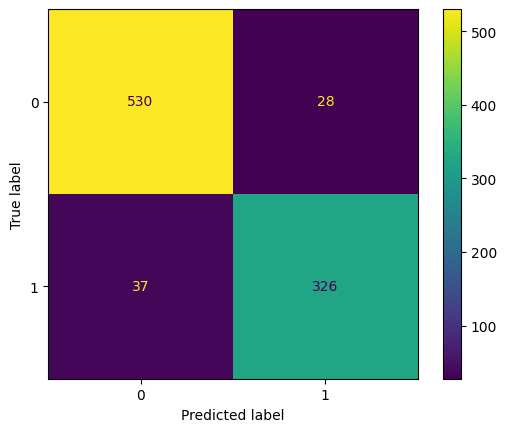

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Pipeline: scaling + logistic regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


Όπως βλέπουμε η Logistic Regression παρουσιάζει πολύ ικανοποιητική απόδοση, επιτυγχάνοντας ακρίβεια περίπου 93%.
(accuracy 0.9294).

Το μοντέλο καταφέρνει να διαχωρίζει αποτελεσματικά τα spam από τα κανονικά email, διατηρώντας παράλληλα χαμηλό αριθμό λανθασμένων χαρακτηρισμών κανονικών email ως spam.

Ιδιαίτερα σημαντικό είναι το γεγονός ότι τα false positives είναι περιορισμένα (False Positives (FP) είναι τα κανονικά email που προβλέφθηκαν ως spam και όπως βλέπουμε είναι 28 μόνο), κάτι που είναι σημαντικό.

Συνεπώς, η Logistic Regression αποτελεί ένα αξιόπιστο και ισχυρό μοντέλο, το οποίο μπορεί να χρησιμοποιηθεί ως σημείο αναφοράς για τη σύγκριση με πιο σύνθετους αλγορίθμους μηχανικής μάθησης που θα εξεταστούν στη συνέχεια.

Επομένως , το παραπάνω διάγραμμα μας δείχνει τα εξής:



*   530: σωστά κανονικά
*   326: σωστά spam
*   28: κανονικά που έγιναν λάθος spam → false positives
*   37: spam που έγιναν λάθος κανονικά → false negatives

Από τα 921 emails:

*    τα 856 ταξινομήθηκαν σωστά
*    τα 65 λάθος









#Naive Bayes

Τώρα θα φτιάξουμε Naive Bayes, που είναι κλασικό για spam filtering και πολύ καλό για σύγκριση.

Επειδή τα features είναι συνεχείς τιμές, θα χρησιμοποιήσουμε Gaussian Naive Bayes.
Εδώ ΔΕΝ χρειάζεται κανονικοποίηση, γιατί το μοντέλο δουλεύει με κατανομές πιθανοτήτων.

              precision    recall  f1-score   support

           0     0.9613    0.7563    0.8465       558
           1     0.7178    0.9532    0.8189       363

    accuracy                         0.8339       921
   macro avg     0.8396    0.8547    0.8327       921
weighted avg     0.8653    0.8339    0.8357       921



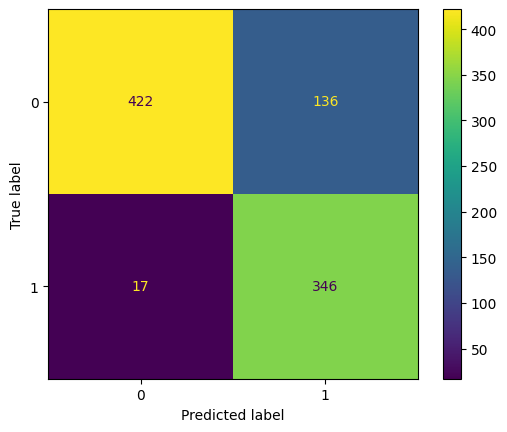

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Naive Bayes
# Den xreiazetai scaling edw giati doulevei me pithanotites/katonomes

nb = GaussianNB()

# Ekpaideusi sto train set
nb.fit(X_train, y_train)

# Provlepseis sto test set
y_pred_nb = nb.predict(X_test)

# emfanish gia symperasmata me precision/recall/f1
print(classification_report(y_test, y_pred_nb, digits=4))

# Confusion matrix gia na doume kai ta false positives/false negatives
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.show()


Το μοντέλο Naive Bayes εμφανίζει χαμηλότερη συνολική απόδοση σε σύγκριση με τη Logistic Regression, με accuracy περίπου 83,4%.
(Όπως βλέπουμε παραπάνω είναι:  accuracy 0.8339)

Αν και εντοπίζει αποτελεσματικά τα spam email (υψηλό recall για την κλάση 1: (recall 0.9532), παρουσιάζει σημαντικό πρόβλημα στον αριθμό των false positives.

Από τον πίνακα βλέπουμε:

* False Positives = 136 (κανονικά email που ταξινομήθηκαν ως spam),

* True Positives = 346,

* True Negatives = 422,

* False Negatives = 17.

Ο αριθμός των 136 false positives είναι μεγάλος και ανεπιθύμητος για ένα σύστημα που φιλτράρει email, καθώς σημαίνει ότι πολλά κανονικά μηνύματα θα κατέληγαν λανθασμένα στον φάκελο με τα spam.

**ΣΥΓΚΡΙΣΗ ΜΕ Logistic Regression**

Η Logistic Regression είχε μόνο 28 false positives,
ενώ το Naive Bayes έχει 136 ,  αρκετά παραπάνω.

Το μοντέλο Naive Bayes, παρότι πετυχαίνει ικανοποιητική ανίχνευση των spam email, παρουσιάζει αυξημένο αριθμό false positives σε σύγκριση με τη Logistic Regression.

Το γεγονός αυτό το καθιστά λιγότερο κατάλληλο για όταν θέλουμε να φιλτράρουμε emails σε spam και μη spam, όπου η λανθασμένη απόρριψη κανονικών email είναι κάτι σοβαρό.

Συνεπώς, η Logistic Regression έχει προβάδισμα ως προς την ισορροπία μεταξύ accuracy και περιορισμού των false positives.

---


 # SVM (Support Vector Machine)

              precision    recall  f1-score   support

           0     0.9270    0.9552    0.9409       558
           1     0.9277    0.8843    0.9055       363

    accuracy                         0.9273       921
   macro avg     0.9274    0.9197    0.9232       921
weighted avg     0.9273    0.9273    0.9269       921



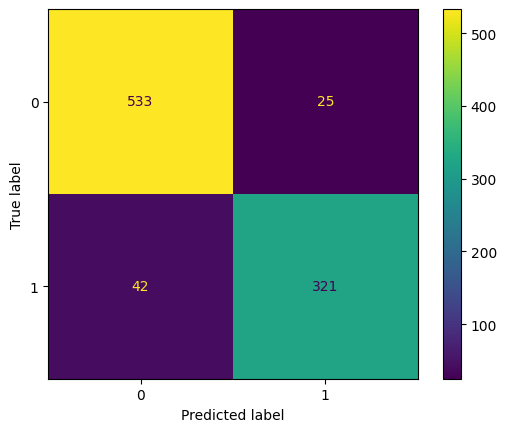

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# SVM me scaling (opws sthn Logistic Regression)
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipe_svm.fit(X_train, y_train)

y_pred_svm = pipe_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm, digits=4))

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot()
plt.show()


Βάσει του πίνακα έχουμε:

* True Negatives = 533
* True Positives = 321
* False Positives = 25
* False Negatives = 42

Τα False Positives είναι 25. Δηλαδή 25 κανονικά email χαρακτηρίστηκαν λανθασμένα ως spam.

Το accuracy είναι περίπου 92.7% (accuracy 0.9273) , δηλαδή το μοντέλο ταξινομεί σωστά περίπου 93 στα 100 email.

**Συμπέρασμα:** Το μοντέλο SVM παρουσιάζει πολύ καλή απόδοση, με accuracy περίπου 92,7%, παρόμοια με αυτή της Logistic Regression.
Ωστόσο, εμφανίζει μικρότερο αριθμό false positives (25 η SVM σε σχέση με τα 28 της Logistic Regression) , γεγονός που το καθιστά ακόμα καλύτερο για επιλογή όταν θέλουμε να φιλτράρουμε τα emails, όπου η λανθασμένη απόρριψη κανονικών μηνυμάτων πρέπει να αποφεύγεται.
Συνεπώς, το SVM φαίνεται να είναι ως ένα από τα πιο κατάλληλα μοντέλα για το συγκεκριμένο πρόβλημα.
Μέχρι τώρα τουλάχιστον...

#Random Forest

              precision    recall  f1-score   support

           0     0.9425    0.9695    0.9558       558
           1     0.9510    0.9091    0.9296       363

    accuracy                         0.9457       921
   macro avg     0.9468    0.9393    0.9427       921
weighted avg     0.9459    0.9457    0.9455       921



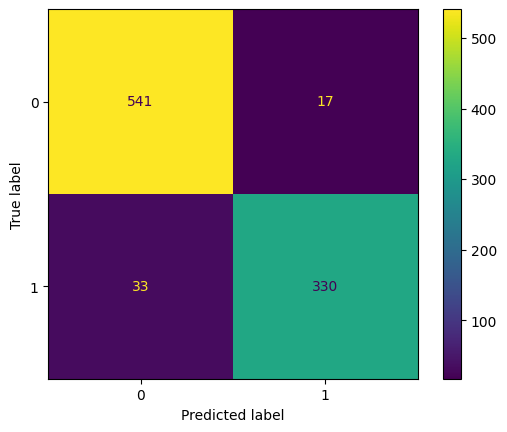

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest - den xreiazetai scaling
rf = RandomForestClassifier(
    n_estimators=300,      # arketra dentra gia statherotita
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, digits=4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.show()


Από τον πίνακα βλέπουμε τα εξής:

* True Negatives = 541
* True Positives = 330
* False Positives = 17
* False Negatives = 33


Το μοντέλο ταξινομεί σωστά περίπου 95 στα 100 email. Αυτό το βλέπουμε από το accuracy = 0.9457 , κοντά στο 95% δηλαδή.

Τα False Positives = 17 είναι πολύ χαμηλά και μέχρι στιγμής είναι το καλύτερο αποτέλεσμα που έχουμε δει.

Αυτό σημαίνει ότι πολύ λίγα κανονικά email χαρακτηρίζονται λανθασμένα ως spam, κάτι που θέλουμε.

Ο Random Forest παρουσιάζει την καλύτερη απόδοση από όλα τα μοντέλα που εξετάστηκαν μέχρι στιγμής, επιτυγχάνοντας ακρίβεια περίπου 94,6% και τον μικρότερο αριθμό false positives.

Το αποτέλεσμα αυτό τον καθιστά ιδιαίτερα κατάλληλο για το πρόβλημα ανίχνευσης spam, καθώς συνδυάζει υψηλή συνολική ακρίβεια με ελαχιστοποίηση των λανθασμένων χαρακτηρισμών κανονικών email ως ανεπιθύμητων.

# k-NN

              precision    recall  f1-score   support

           0     0.9216    0.9265    0.9240       558
           1     0.8861    0.8788    0.8824       363

    accuracy                         0.9077       921
   macro avg     0.9038    0.9027    0.9032       921
weighted avg     0.9076    0.9077    0.9076       921



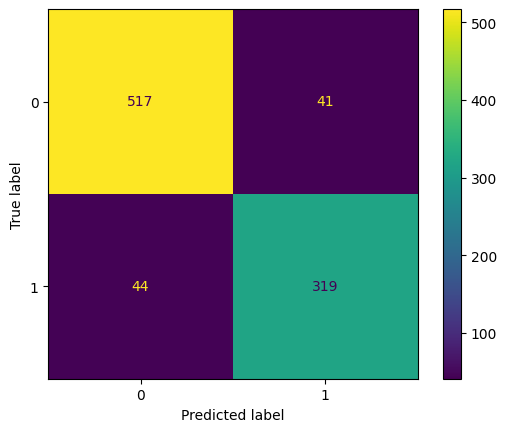

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# k-NN thelei scaling
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipe_knn.fit(X_train, y_train)

y_pred_knn = pipe_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn, digits=4))

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.show()


Από τον πίνακα καταλαβαίνουμε τα εξής:

* True Negatives = 517
* True Positives = 319
* False Positives = 41
* False Negatives = 44

Το accuracy είναι περίπου 90.8%. (accuracy 0.9077)
Τα False Positives = 41, δηλαδή 41 κανονικά email χαρακτηρίστηκαν λάθος ως spam. Αυτό είναι πολύ υψηλό και δεν είναι πολύ καλό.


Το μοντέλο k-NN παρουσιάζει καλή συνολική απόδοση, με accuracy περίπου 90,8%, ωστόσο εμφανίζει υψηλό αριθμό false positives σε σύγκριση με τα προηγούμενα μοντέλα.

Το γεγονός αυτό το καθιστά λιγότερο κατάλληλο για εφαρμογές που ανιχνεύουμε spam, όπου προτεραιότητα έχει η να αποφεύγουμε να χαρακτηρίζουμε spam τα κανονικά emails.

# Gradient Boosting

              precision    recall  f1-score   support

           0     0.9556    0.9642    0.9599       558
           1     0.9441    0.9311    0.9376       363

    accuracy                         0.9511       921
   macro avg     0.9499    0.9476    0.9487       921
weighted avg     0.9511    0.9511    0.9511       921



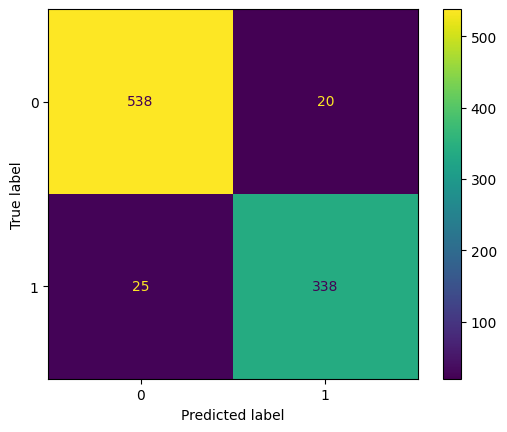

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gradient Boosting - den xreiazetai scaling
gb = HistGradientBoostingClassifier(
    max_depth=6,
    max_iter=200,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb, digits=4))

cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot()
plt.show()


Από τον πίνακα καταλαβαίνουμε τα εξής:

* True Negatives = 538
* True Positives = 338
* False Positives = 20
* False Negatives = 25

Το accuracy είναι περίπου 95.1%. (accuracy 0.9511)
Τα False Positives = 20, δηλαδή 20 κανονικά email χαρακτηρίστηκαν λάθος ως spam. Είναι κοντά στην καλύτερη τιμή που είχαμε στη random forest με 17.

Το μοντέλο Gradient Boosting παρουσιάζει την υψηλότερη συνολική απόδοση, επιτυγχάνοντας ακρίβεια περίπου 95,1%.

Παράλληλα, έχει πολύ χαμηλό αριθμό false positives, γεγονός που το καθιστά ιδιαίτερα αποτελεσματικό για το πρόβλημα ανίχνευσης spam.

Σε σύγκριση με τον Random Forest, εμφανίζει ελαφρώς καλύτερη συνολική ακρίβεια, ενώ ο Random Forest είναι οριακά καλύτερος ως προς την ελαχιστοποίηση των false positives.

Ακολουθεί σύντομος πίνακας σχετικά με όλους τους αλγορίθμους και συνοπτικά αποτελέσματα τους.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def eval_model(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_spam(1)": precision_score(y_true, y_pred, pos_label=1),
        "Recall_spam(1)": recall_score(y_true, y_pred, pos_label=1),
        "F1_spam(1)": f1_score(y_true, y_pred, pos_label=1),
        "False_Positive": fp,
        "False_Negative": fn
    }

results = []

#  xrisimopoioume ta y_pred pou exoyme idi ftiaxei
results.append(eval_model("Logistic Regression", y_test, y_pred))
results.append(eval_model("Naive Bayes (Gaussian)", y_test, y_pred_nb))
results.append(eval_model("SVM (RBF)", y_test, y_pred_svm))
results.append(eval_model("Random Forest", y_test, y_pred_rf))
results.append(eval_model("k-NN (k=5)", y_test, y_pred_knn))
results.append(eval_model("Gradient Boosting", y_test, y_pred_gb))

df_results = pd.DataFrame(results)

# morfopoihsh gia na fainontai omorfa
df_results["Accuracy"] = df_results["Accuracy"].map(lambda x: round(x, 4))
df_results["Precision_spam(1)"] = df_results["Precision_spam(1)"].map(lambda x: round(x, 4))
df_results["Recall_spam(1)"] = df_results["Recall_spam(1)"].map(lambda x: round(x, 4))
df_results["F1_spam(1)"] = df_results["F1_spam(1)"].map(lambda x: round(x, 4))

# Taxinomisi prwta ligotera False Positives, meta megalytero Accuracy
df_results_sorted = df_results.sort_values(by=["False_Positive", "Accuracy"], ascending=[True, False])

df_results_sorted


,Model,Accuracy,Precision_spam(1),Recall_spam(1),F1_spam(1),False_Positive,False_Negative
3,Random Forest,0.9457,0.9510,0.9091,0.9296,17,33
5,Gradient Boosting,0.9511,0.9441,0.9311,0.9376,20,25
2,SVM (RBF),0.9273,0.9277,0.8843,0.9055,25,42
0,Logistic Regression,0.9294,0.9209,0.8981,0.9093,28,37
4,k-NN (k=5),0.9077,0.8861,0.8788,0.8824,41,44
1,Naive Bayes (Gaussian),0.8339,0.7178,0.9532,0.8189,136,17


Τα πειραματικά αποτελέσματα δείχνουν ξεκάθαρα διαφορές στην απόδοση των αλγορίθμων, με βασικό κριτήριο όχι μόνο τη συνολική ακρίβεια (accuracy) αλλά και τον περιορισμό των false positives (δηλαδή κανονικά email που χαρακτηρίζονται λανθασμένα ως spam).

Οι γραμμικοί ταξινομητές (Logistic Regression και SVM) πέτυχαν παρόμοια και υψηλή ακρίβεια (~92 και ~93%), με σχετικά χαμηλά false positives (28 και 25 αντίστοιχα) άρα αποτελούν ισχυρά  μοντέλα.

Αντίθετα, το Naive Bayes παρότι εντόπισε αρκετά spam (υψηλό recall) εμφάνισε πολύ μεγάλο αριθμό false positives (136), γεγονός που το καθιστά ακατάλληλο για φίλτρα email.

Το k-NN είχε μέτρια επίδοση (~90,8%) και αυξημένα false positives (41), υστερώντας σε σύγκριση με τα υπόλοιπα.

Οι δενδροειδείς μέθοδοι (Random Forest και Gradient Boosting) είχαν την καλύτερη συνολική εικόνα.

Ο Random Forest πέτυχε υψηλή ακρίβεια (~94,6%) και τον μικρότερο αριθμό false positives (17), που είναι κρίσιμο για την αποφυγή απόρριψης κανονικών email.

Το Gradient Boosting έδωσε την υψηλότερη ακρίβεια (~95,1%) με επίσης πολύ χαμηλά false positives (20), δείχνοντας  ισορροπία μεταξύ ανίχνευσης spam και κανονικών email.

Συνολικά, τα αποτελέσματα υποδεικνύουν ότι τα ισχυρότερα μοντέλα για το συγκεκριμένο dataset είναι τα Random Forest και Gradient Boosting, με μικρές μεταξύ τους διαφορές ανάλογα με το αν δίνουμε προτεραιότητα στη μέγιστη ακρίβεια ή στην περαιτέρω μείωση των false positives.

---

---

---

Στο επόμενο στάδιο θα πραγματοποιηθεί ρύθμιση των παραμέτρων (parameter tuning) των πιο αποδοτικών μοντέλων, με στόχο τη βελτιστοποίηση της απόδοσής τους.

Μέχρι στιγμής, όλοι οι αλγόριθμοι έχουν χρησιμοποιηθεί με τις προεπιλεγμένες ρυθμίσεις τους, οι οποίες δεν είναι απαραίτητα οι καταλληλότερες για το συγκεκριμένο σύνολο δεδομένων.

Μέσω της διαδικασίας αυτής επιδιώκεται η εύρεση του βέλτιστου συνδυασμού παραμέτρων που μεγιστοποιεί την ακρίβεια ταξινόμησης και, κυρίως, ελαχιστοποιεί τον αριθμό των false positives, που αποτελεί κρίσιμο κριτήριο για εφαρμογές φιλτραρίσματος ανεπιθύμητης αλληλογραφίας.

Για τον σκοπό αυτό θα χρησιμοποιηθεί η μέθοδος GridSearchCV, η οποία επιτρέπει τη συστηματική διερεύνηση διαφορετικών συνδυασμών παραμέτρων σε συνδυασμό με τεχνικές cross-validation.

Αρχικά θα εφαρμοστεί στο μοντέλο Random Forest, το οποίο παρουσίασε τον μικρότερο αριθμό false positives, και στη συνέχεια στο μοντέλο Gradient Boosting, το οποίο πέτυχε τη μεγαλύτερη συνολική ακρίβεια.

Με τον τρόπο αυτό επιδιώκεται η περαιτέρω βελτίωση των ήδη ισχυρών μοντέλων και η ανάδειξη της βέλτιστης τελικής λύσης για το πρόβλημα ταξινόμησης spam emails.

# GridSearchCV για Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Orizoume to montelo
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Orizoume to grid twn parametron pou tha dokimastoun
param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

# GridSearch me 5-fold cross validation
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",   # mporoume na valoume kai "accuracy" ή "recall"
    n_jobs=-1,
    verbose=2
)

# Ekkinisi grid search
grid_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:")
print(grid_rf.best_params_)

print("\nBest cross-validation score:")
print(grid_rf.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest:
{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation score:
0.9419862421495839


# Εκπαίδευση του βελτιστοποιημένου Random Forest

Οι νέοι παράμετροι είναι:

n_estimators = 200  (200 δέντρα)

max_depth = None (χωρίς περιορισμό βάθους)

min_samples_split = 2  (κανονικός διαχωρισμός)

max_features = 'log2'  (κάθε split βλέπει log2(features))

              precision    recall  f1-score   support

           0     0.9476    0.9731    0.9602       558
           1     0.9569    0.9174    0.9367       363

    accuracy                         0.9511       921
   macro avg     0.9523    0.9452    0.9485       921
weighted avg     0.9513    0.9511    0.9509       921



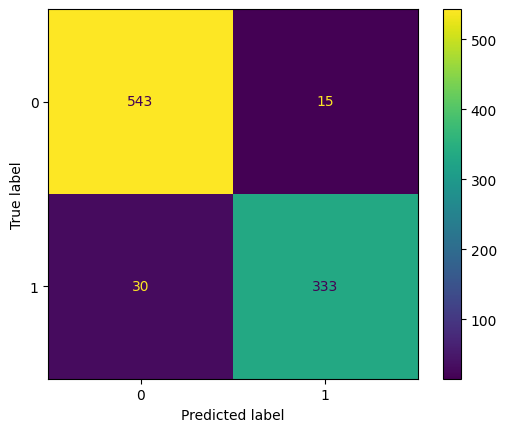

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Neo Random Forest me tis beltistes parametrous
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    max_features="log2",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

# Provlepseis sto test set
y_pred_rf_tuned = rf_tuned.predict(X_test)

print(classification_report(y_test, y_pred_rf_tuned, digits=4))

# Confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned)
disp_rf_tuned.plot()
plt.show()


Μειώσαμε κι άλλο τα false positives και ανεβάσαμε την ακρίβεια.

Αυτό είναι ακριβώς ο στόχος του parameter tuning.

Στον πίνακα βλέπουμε:

* True Negatives = 543
* True Positives = 333
* False Positives = 15
* False Negatives = 30




Η εφαρμογή GridSearchCV στον Random Forest οδήγησε σε περαιτέρω βελτίωση της απόδοσης του μοντέλου.

Η συνολική ακρίβεια αυξήθηκε σε 95.11%, ενώ ο αριθμός των false positives μειώθηκε από 17 σε 15.

Το αποτέλεσμα αυτό επιβεβαιώνει ότι η ρύθμιση των υπερπαραμέτρων μπορεί να βελτιώσει τόσο τη γενική απόδοση όσο και την πρακτική χρησιμότητα ενός συστήματος φιλτραρίσματος spam, περιορίζοντας ακόμη περισσότερο τη λανθασμένη απόρριψη κανονικών email.

# GridSearchCV για Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = HistGradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "max_depth": [3, 6, 9],
    "max_iter": [100, 200, 400],
    "learning_rate": [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring="f1",   # idio criterio gia dikaii sugkrisi
    n_jobs=-1,
    verbose=2
)

grid_gb.fit(X_train, y_train)

print("Best parameters for Gradient Boosting:")
print(grid_gb.best_params_)

print("\nBest cross-validation score:")
print(grid_gb.best_score_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 9, 'max_iter': 200}

Best cross-validation score:
0.9463676000377245


# Εκπαίδευση του βελτιστοποιημένου Gradient Boosting

Οι νέοι παράμετροι είναι:

* learning_rate = 0.1

* max_depth = 9

* max_iter = 200

              precision    recall  f1-score   support

           0     0.9601    0.9498    0.9550       558
           1     0.9241    0.9394    0.9317       363

    accuracy                         0.9457       921
   macro avg     0.9421    0.9446    0.9433       921
weighted avg     0.9459    0.9457    0.9458       921



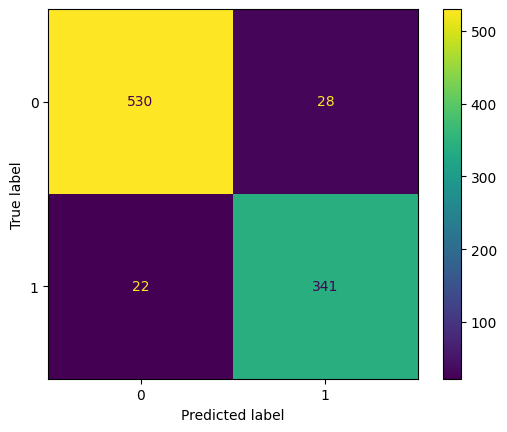

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gradient Boosting me tis beltistes parametrous
gb_tuned = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=9,
    max_iter=200,
    random_state=42
)

# Ekpaideusi
gb_tuned.fit(X_train, y_train)

# Provlepseis sto test set
y_pred_gb_tuned = gb_tuned.predict(X_test)

# Apotelesmata
print(classification_report(y_test, y_pred_gb_tuned, digits=4))

# Confusion matrix
cm_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)
disp_gb_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_gb_tuned)
disp_gb_tuned.plot()
plt.show()


Από τον πίνακα βλέπουμε:

* True Negatives = 530
* True Positives = 341
* False Positives = 28
* False Negatives = 22

Το accuracy είναι 94.57%, δηλαδή χαμηλότερο από το αρχικό Gradient Boosting (95.11%) και χαμηλότερο από τον tuned Random Forest (95.11%).

Επίσης, τα False Positives = 28, που είναι περισσότερα από:

* Τον tuned Random Forest (15),

* και περισσότερα από το αρχικό Gradient Boosting (20).

Άρα, παρότι το GridSearch έδωσε καλό cross-validation score, στο ανεξάρτητο test set:

* Το μοντέλο δεν βελτιώθηκε,

και στην πράξη έγινε χειρότερο σε αυτό που μας ενδιαφέρει περισσότερο (false positives).


Παρότι το GridSearchCV για το Gradient Boosting οδήγησε σε υψηλό σκορ κατά το cross validation, η απόδοση στο ανεξάρτητο σύνολο ελέγχου δεν βελτιώθηκε.

Το accuracy μειώθηκε σε 94.57% και ο αριθμός των false positives αυξήθηκε σε 28, σε σύγκριση τόσο με το αρχικό Gradient Boosting όσο και με τον βελτιστοποιημένο Random Forest.

Το αποτέλεσμα αυτό δείχνει ότι η ρύθμιση υπερπαραμέτρων δεν εγγυάται πάντα βελτίωση στο test set και αναδεικνύει τον κίνδυνο υπερπροσαρμογής (overfitting).

# Τελικός πίνακας (default + tuned)

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def eval_model(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision_spam(1)": round(precision_score(y_true, y_pred, pos_label=1), 4),
        "Recall_spam(1)": round(recall_score(y_true, y_pred, pos_label=1), 4),
        "F1_spam(1)": round(f1_score(y_true, y_pred, pos_label=1), 4),
        "FP": fp,
        "FN": fn
    }

final_results = []

final_results.append(eval_model("Logistic Regression", y_test, y_pred))
final_results.append(eval_model("Naive Bayes (Gaussian)", y_test, y_pred_nb))
final_results.append(eval_model("SVM (RBF)", y_test, y_pred_svm))
final_results.append(eval_model("Random Forest (default)", y_test, y_pred_rf))
final_results.append(eval_model("k-NN (k=5)", y_test, y_pred_knn))
final_results.append(eval_model("Gradient Boosting (default)", y_test, y_pred_gb))

# tuned models (an yparxoun)
final_results.append(eval_model("Random Forest (tuned)", y_test, y_pred_rf_tuned))
final_results.append(eval_model("Gradient Boosting (tuned)", y_test, y_pred_gb_tuned))

df_final = pd.DataFrame(final_results)

# Taxinomisi me vasi to kritirio mas: ligotera FP, meta megalyteri accuracy
df_final_sorted = df_final.sort_values(by=["FP", "Accuracy"], ascending=[True, False]).reset_index(drop=True)

df_final_sorted


,Model,Accuracy,Precision_spam(1),Recall_spam(1),F1_spam(1),FP,FN
0,Random Forest (tuned),0.9511,0.9569,0.9174,0.9367,15,30
1,Random Forest (default),0.9457,0.9510,0.9091,0.9296,17,33
2,Gradient Boosting (default),0.9511,0.9441,0.9311,0.9376,20,25
3,SVM (RBF),0.9273,0.9277,0.8843,0.9055,25,42
4,Gradient Boosting (tuned),0.9457,0.9241,0.9394,0.9317,28,22
5,Logistic Regression,0.9294,0.9209,0.8981,0.9093,28,37
6,k-NN (k=5),0.9077,0.8861,0.8788,0.8824,41,44
7,Naive Bayes (Gaussian),0.8339,0.7178,0.9532,0.8189,136,17


Με βάση τον τελικό πίνακα, το καλύτερο μοντέλο για το πρόβλημα ανίχνευσης spam είναι ο Random Forest μετά το tuning.

Παρουσιάζει την υψηλότερη ακρίβεια (accuracy 95.11%) και ταυτόχρονα τον μικρότερο αριθμό false positives (15), δηλαδή τις λιγότερες περιπτώσεις όπου κανονικά email χαρακτηρίζονται λανθασμένα ως spam.

Αυτό είναι ιδιαίτερα σημαντικό σε εφαρμογές που φιλτράρουν spam emails, όπου η λανθασμένη απόρριψη κανονικών μηνυμάτων θεωρείται σφάλμα.

Συνεπώς, ο tuned Random Forest αποτελεί την πιο κατάλληλη τελική επιλογή μοντέλου για το συγκεκριμένο dataset.

Η διαδικασία του parameter tuning έδειξε ότι η ρύθμιση των υπερπαραμέτρων μπορεί να βελτιώσει ουσιαστικά την απόδοση ενός μοντέλου, όπως φάνηκε στην περίπτωση του Random Forest, όπου μειώθηκαν περαιτέρω τα false positives και αυξήθηκε η συνολική ακρίβεια.

Αντίθετα, στο Gradient Boosting το tuning δεν οδήγησε σε καλύτερα αποτελέσματα στο test set, γεγονός που δείχνει ότι δεν εγγυάται πάντα βελτίωση και μπορεί να οδηγήσει σε υπερπροσαρμογή.

Αυτό υπογραμμίζει τη σημασία της αξιολόγησης των μοντέλων σε ανεξάρτητα δεδομένα και όχι μόνο βάσει των αποτελεσμάτων του cross-validation.